In [2]:
import pandas as pd

df_ltv = pd.read_csv("../data/telco_churn_cleaned.csv")

print(df_ltv.shape)
df_ltv.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df_ltv.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
df_ltv["TotalCharges"] = pd.to_numeric(
    df_ltv["TotalCharges"],
    errors="coerce"
)

print(df_ltv["TotalCharges"].isnull().sum())

0


In [5]:
df_ltv["TotalCharges"] = df_ltv["TotalCharges"].fillna(0)

In [6]:
df_active = df_ltv[df_ltv["Churn"] == "No"].copy()

print("Active customers:", len(df_active))

Active customers: 5174


In [7]:
ltv_features = [
    "tenure",
    "MonthlyCharges"
]

X_ltv = df_active[ltv_features]
y_ltv = df_active["TotalCharges"]

print(X_ltv.head())
print(y_ltv.head())

   tenure  MonthlyCharges
0       1           29.85
1      34           56.95
3      45           42.30
6      22           89.10
7      10           29.75
0      29.85
1    1889.50
3    1840.75
6    1949.40
7     301.90
Name: TotalCharges, dtype: float64


In [8]:
from sklearn.model_selection import train_test_split

X_ltv_train, X_ltv_test, y_ltv_train, y_ltv_test = train_test_split(
    X_ltv,
    y_ltv,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_ltv_train))
print("Testing rows:", len(X_ltv_test))

Training rows: 4139
Testing rows: 1035


In [9]:
from sklearn.ensemble import RandomForestRegressor

ltv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

ltv_model.fit(X_ltv_train, y_ltv_train)

print("LTV model trained successfully!")

LTV model trained successfully!


In [10]:
ltv_pred = ltv_model.predict(X_ltv_test)

print(ltv_pred[:10])

[  20.165      1373.96615     331.942       976.94538333  921.35925
  415.6534753   911.803       452.27375     444.22240982 2812.319     ]


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_ltv_test, ltv_pred)
rmse = np.sqrt(mean_squared_error(y_ltv_test, ltv_pred))
r2 = r2_score(y_ltv_test, ltv_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 58.26592526445454
RMSE: 83.9582323892081
R²: 0.998703730950058


In [12]:
df_active["predicted_ltv"] = ltv_model.predict(
    df_active[ltv_features]
)

df_active[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "predicted_ltv"
]].head()

,tenure,MonthlyCharges,TotalCharges,predicted_ltv
0,1,29.85,29.85,30.10350
1,34,56.95,1889.50,1871.94200
3,45,42.30,1840.75,1891.24575
6,22,89.10,1949.40,1931.32750
7,10,29.75,301.90,303.07100


In [14]:
# Encode categorical columns
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("X_encoded shape:", X_encoded.shape)
print(X_encoded.head())

NameError: name 'X' is not defined

In [15]:
import pandas as pd

# Load the CSV that actually exists in your data folder
df = pd.read_csv("../data/telco_churn.csv")

print("Data loaded successfully")
print(df.shape)
print(df.head())

Data loaded successfully
(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV 

In [16]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target values:", y.unique())

X shape: (7043, 20)
y shape: (7043,)
Target values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [17]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("X_encoded shape:", X_encoded.shape)

C:\Users\Hp\AppData\Local\Temp\ipykernel_18420\1514001778.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


X_encoded shape: (7043, 13601)


In [18]:
X_all = X_encoded.copy()

print("X_all shape:", X_all.shape)

X_all shape: (7043, 13601)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 13601)
X_test: (1409, 13601)
y_train: (5634,)
y_test: (1409,)


In [21]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [22]:
y_pred = logistic_model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No']


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7955997161107168

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Confusion Matrix:
[[920 115]
 [173 201]]


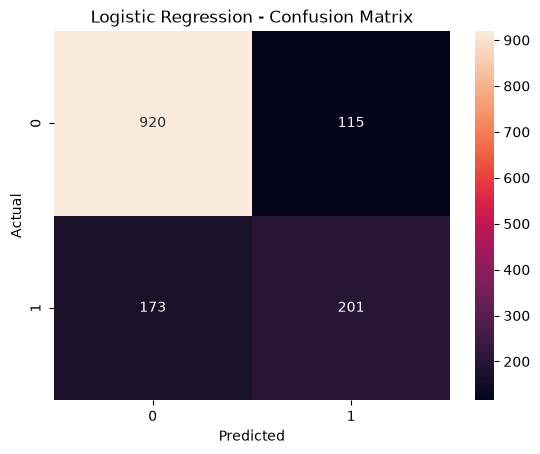

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [25]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head(10))

     Actual Predicted
437      No        No
2280     No       Yes
2235     No        No
4460     No        No
3761     No        No
5748     No       Yes
3568     No        No
2976     No        No
5928     No        No
1639    Yes        No


In [26]:

churn_probability = logistic_model.predict_proba(X_all)[:, 1]

print(churn_probability[:10])
print("Number of customers:", len(churn_probability))

[0.37539225 0.04205338 0.50471691 0.03068905 0.77698265 0.86054844
 0.49695306 0.25911506 0.73924827 0.01158428]
Number of customers: 7043


In [27]:
df_customer = df.copy()

df_customer["churn_probability"] = churn_probability

df_customer[[
    "customerID",
    "Churn",
    "churn_probability"
]].head(10)

,customerID,Churn,churn_probability
0,7590-VHVEG,No,0.375392
1,5575-GNVDE,No,0.042053
2,3668-QPYBK,Yes,0.504717
3,7795-CFOCW,No,0.030689
4,9237-HQITU,Yes,0.776983
5,9305-CDSKC,Yes,0.860548
6,1452-KIOVK,No,0.496953
7,6713-OKOMC,No,0.259115
8,7892-POOKP,Yes,0.739248
9,6388-TABGU,No,0.011584


In [28]:
def churn_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df_customer["churn_risk"] = df_customer["churn_probability"].apply(
    churn_risk
)

In [29]:
df_customer["churn_risk"].value_counts()

churn_risk
Low Risk       5057
Medium Risk    1158
High Risk       828
Name: count, dtype: int64

In [30]:
high_risk_customers = df_customer.sort_values(
    "churn_probability",
    ascending=False
)

high_risk_customers[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "churn_probability",
        "churn_risk"
    ]
].head(20)

,customerID,tenure,MonthlyCharges,churn_probability,churn_risk
4624,0325-XBFAC,8,94.70,0.906985,High Risk
1976,9497-QCMMS,1,93.55,0.899276,High Risk
4800,9300-AGZNL,1,94.00,0.898889,High Risk
6368,2720-WGKHP,2,94.00,0.896253,High Risk
2208,7216-EWTRS,1,100.80,0.895536,High Risk
5989,5567-WSELE,3,94.60,0.894235,High Risk
1410,7024-OHCCK,2,93.85,0.894113,High Risk
3467,8414-MYSHR,5,91.40,0.892670,High Risk
997,1374-DMZUI,4,94.30,0.888192,High Risk
3749,4424-TKOPW,2,93.85,0.887837,High Risk


In [31]:
df_customer.to_csv(
    "../data/customer_churn_predictions.csv",
    index=False
)

print("Churn predictions saved successfully!")

Churn predictions saved successfully!
